PART 1(a): Histogram, KDE and true f(x)

Monte Carlo estimate of mean : 0.01946
  (theoretical value         :  0.00000)

Monte Carlo estimate of std  : 1.49280
  (theoretical value         :  1.41421)


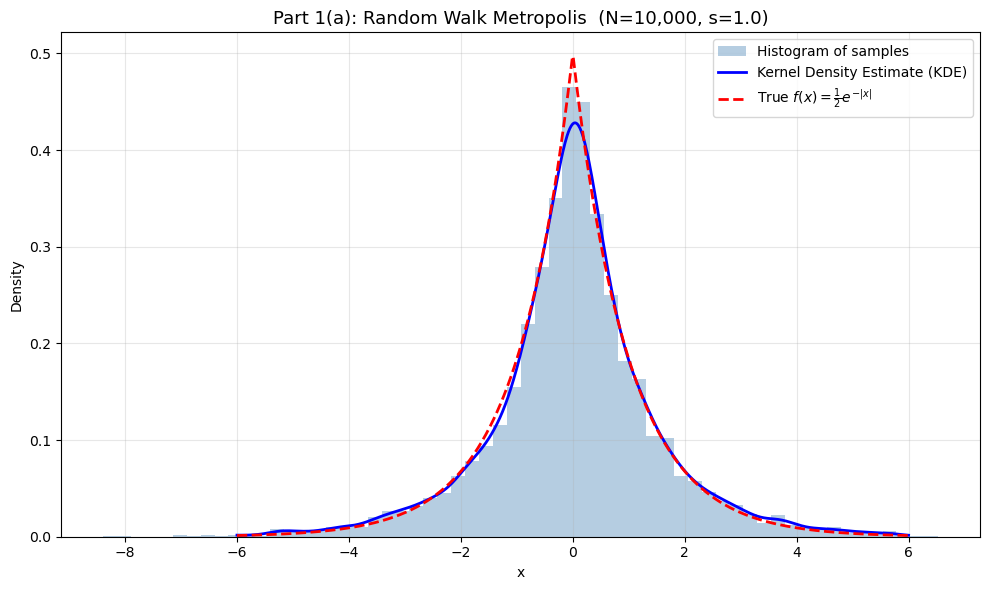


PART 1(b): R-hat convergence diagnostic

R-hat at s = 0.001 : 56.95180
(a value much larger than 1.05 suggests the chains haven't converged)

Computing R-hat across s grid (this may take a moment)...


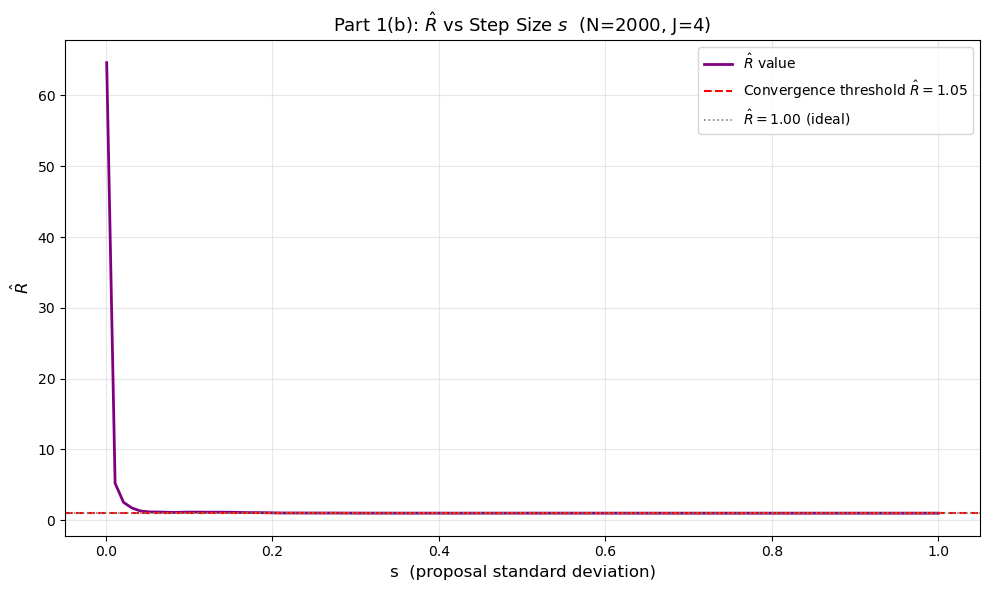


Lowest  R-hat : 1.0001  at s = 0.7376
Highest R-hat : 64.6252  at s = 0.0010

Interpretation: very small s means the chain moves slowly and gets
stuck, so R-hat is high. As s increases the chain explores better
and R-hat drops toward 1.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

def log_f(x):
    return -np.abs(x) - np.log(2)

def true_f(x):
    return 0.5 * np.exp(-np.abs(x))

def random_walk_metropolis(N, s, x0=0.0, seed=None):
    rng = np.random.default_rng(seed)
    samples = np.empty(N)
    x_curr = x0
    log_f_curr = log_f(x_curr)
    
    for i in range(N):
        x_prop = rng.normal(x_curr, s)
        log_f_prop = log_f(x_prop)
        
        log_r = log_f_prop - log_f_curr
        log_u = np.log(rng.uniform())
        
        if log_u < log_r:
            x_curr = x_prop
            log_f_curr = log_f_prop
            
        samples[i] = x_curr
        
    return samples

print("=" * 55)
print("PART 1(a): Histogram, KDE and true f(x)")
print("=" * 55)

N_a = 10000
s_a = 1.0
samples_a = random_walk_metropolis(N_a, s_a, x0=0.0, seed=42)

sample_mean = np.mean(samples_a)
sample_std  = np.std(samples_a, ddof=1)

print(f"\nMonte Carlo estimate of mean : {sample_mean:.5f}")
print(f"  (theoretical value         :  0.00000)")
print(f"\nMonte Carlo estimate of std  : {sample_std:.5f}")
print(f"  (theoretical value         :  {np.sqrt(2):.5f})")

x_grid = np.linspace(-6, 6, 1000)
kde = gaussian_kde(samples_a)

plt.figure(figsize=(10, 6))
plt.hist(samples_a, bins=60, density=True, alpha=0.4, color="steelblue", label="Histogram of samples")
plt.plot(x_grid, kde(x_grid), color="blue", lw=2, label="Kernel Density Estimate (KDE)")
plt.plot(x_grid, true_f(x_grid), color="red", lw=2, linestyle="dashed", label=r"True $f(x) = \frac{1}{2}e^{-|x|}$")

plt.title(f"Part 1(a): Random Walk Metropolis  (N={N_a:,}, s={s_a})", fontsize=13)
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("part1a_histogram_kde.png", dpi=150)
plt.show()

print("\n" + "=" * 55)
print("PART 1(b): R-hat convergence diagnostic")
print("=" * 55)

def compute_rhat(J, N, s, base_seed=0):
    chains = np.array([
        random_walk_metropolis(N, s, x0=float(j), seed=base_seed + j)
        for j in range(J)
    ])
    
    Mj = chains.mean(axis=1)
    Vj = ((chains - Mj[:, None])**2).mean(axis=1)
    
    W = Vj.mean()
    M = Mj.mean()
    B = ((Mj - M)**2).mean()
    
    R_hat = np.sqrt((B + W) / W)
    return R_hat

N_b = 2000
J   = 4

rhat_at_0001 = compute_rhat(J, N_b, s=0.001)
print(f"\nR-hat at s = 0.001 : {rhat_at_0001:.5f}")
print("(a value much larger than 1.05 suggests the chains haven't converged)")

s_grid    = np.linspace(0.001, 1.0, 100)
rhat_vals = []

print("\nComputing R-hat across s grid (this may take a moment)...")
for s in s_grid:
    rhat = compute_rhat(J, N_b, s, base_seed=500)
    rhat_vals.append(rhat)

rhat_vals = np.array(rhat_vals)

plt.figure(figsize=(10, 6))
plt.plot(s_grid, rhat_vals, color="purple", lw=2, label=r"$\hat{R}$ value")
plt.axhline(1.05, color="red", linestyle="--", lw=1.5, label=r"Convergence threshold $\hat{R} = 1.05$")
plt.axhline(1.00, color="gray", linestyle=":", lw=1.2, label=r"$\hat{R} = 1.00$ (ideal)")

plt.title(fr"Part 1(b): $\hat{{R}}$ vs Step Size $s$  (N={N_b}, J={J})", fontsize=13)
plt.xlabel("s  (proposal standard deviation)", fontsize=12)
plt.ylabel(r"$\hat{R}$", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("part1b_rhat_plot.png", dpi=150)
plt.show()

idx_min = np.argmin(rhat_vals)
idx_max = np.argmax(rhat_vals)
print(f"\nLowest  R-hat : {rhat_vals[idx_min]:.4f}  at s = {s_grid[idx_min]:.4f}")
print(f"Highest R-hat : {rhat_vals[idx_max]:.4f}  at s = {s_grid[idx_max]:.4f}")
print("\nInterpretation: very small s means the chain moves slowly and gets")
print("stuck, so R-hat is high. As s increases the chain explores better")
print("and R-hat drops toward 1.")